# AI-08: Student Dropout Risk Predictor
**Nigerian Secondary School Context**

This notebook trains a model to predict a student's dropout risk (Low / Medium / High) from attendance, grades, and socio-economic factors, using a synthetic dataset built to reflect real Nigerian dropout drivers (distance to school, household income, part-time work, family support, etc.).

**Pipeline:**
1. Load & explore data
2. Preprocess (encode categoricals, scale numerics)
3. Train Logistic Regression (baseline) + Random Forest (main model)
4. Evaluate (accuracy, precision/recall, confusion matrix)
5. Extract contributing factors (feature importance)
6. Save the trained model
7. Predict risk for a new student (demo function)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

sns.set_style("whitegrid")


## 1. Load the dataset

In [2]:
df = pd.read_csv("nigerian_student_dropout_dataset.csv")
print(df.shape)
df.head()


(1000, 22)


,student_id,state,school_type,gender,age,class_level,distance_to_school_km,household_income_band,parent_education_level,num_siblings,...,family_support,health_issues,attendance_rate_pct,term1_avg_score,term2_avg_score,term3_avg_score,overall_avg_score,extracurricular_involvement,risk_score_raw,dropout_risk_level
0,STU0001,Anambra,Private,Male,17,JSS3,1.1,Middle,Primary,2,...,Yes,No,91.3,60.1,60.9,55.4,58.8,Yes,7.7,Low
1,STU0002,Ogun,Public,Male,18,SS1,1.2,Low,Secondary,6,...,Yes,No,70.7,62.3,42.5,63.8,56.2,Yes,58.4,Medium
2,STU0003,Lagos,Public,Female,11,SS1,3.4,Low,Primary,4,...,No,No,80.7,49.7,45.8,43.0,46.2,Yes,55.3,Medium
3,STU0004,Borno,Private,Female,18,SS1,0.6,Low,Primary,0,...,Yes,No,81.1,68.4,66.4,47.7,60.8,No,25.0,Low
4,STU0005,Benue,Public,Male,17,SS3,1.6,Middle,Secondary,2,...,Yes,No,99.2,73.9,100.0,59.3,77.7,No,2.7,Low


## 2. Quick EDA

In [3]:
df["dropout_risk_level"].value_counts()


,count
dropout_risk_level,
Low,481
Medium,325
High,194


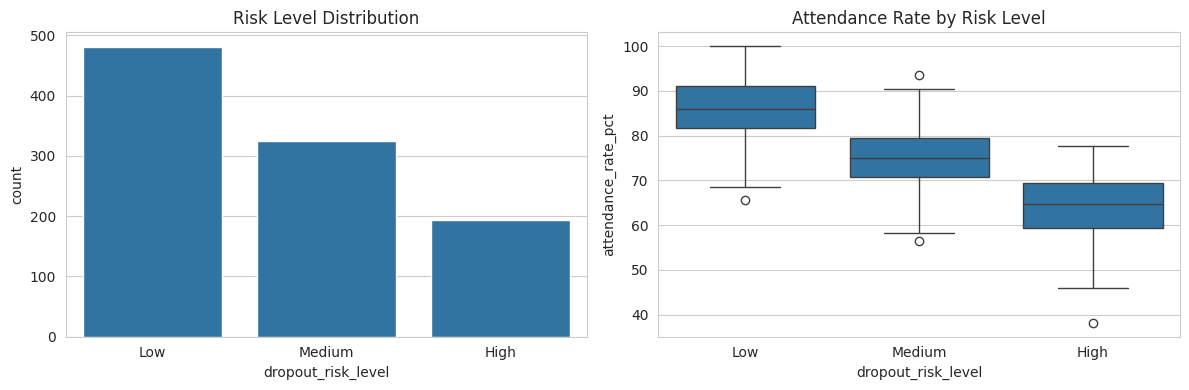

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="dropout_risk_level", order=["Low","Medium","High"], ax=ax[0])
ax[0].set_title("Risk Level Distribution")

sns.boxplot(data=df, x="dropout_risk_level", y="attendance_rate_pct",
            order=["Low","Medium","High"], ax=ax[1])
ax[1].set_title("Attendance Rate by Risk Level")
plt.tight_layout()
plt.show()


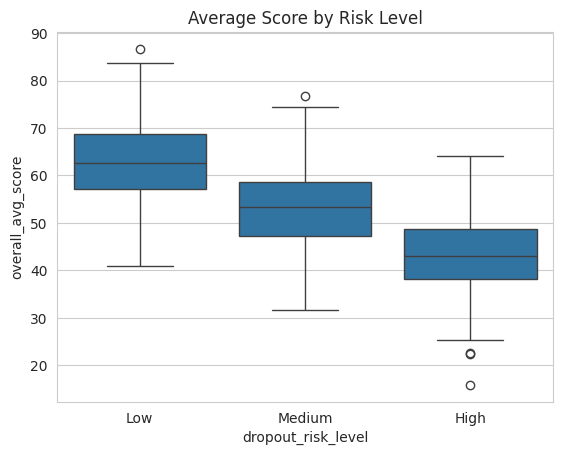

In [5]:
sns.boxplot(data=df, x="dropout_risk_level", y="overall_avg_score", order=["Low","Medium","High"])
plt.title("Average Score by Risk Level")
plt.show()


## 2b. Correlation heatmap (numeric features)

Checking for multicollinearity before modeling -- some numeric features may
carry overlapping information, which is worth knowing before we interpret
feature importance later.


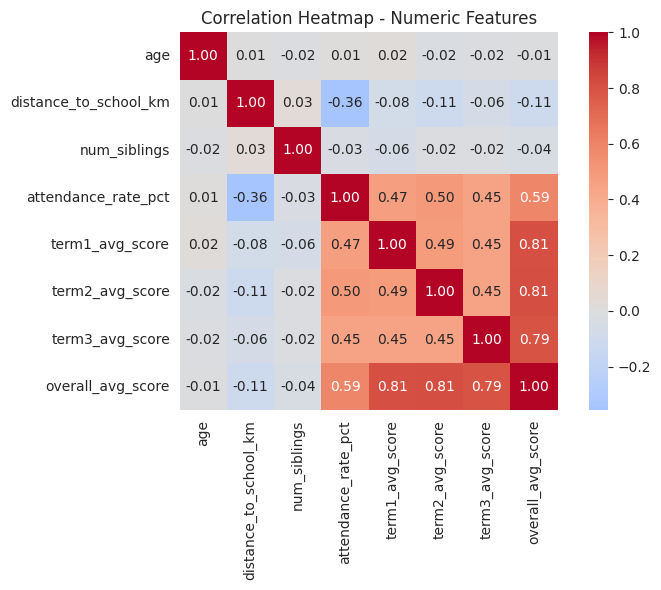

In [6]:
numeric_cols = ["age", "distance_to_school_km", "num_siblings", "attendance_rate_pct",
                "term1_avg_score", "term2_avg_score", "term3_avg_score", "overall_avg_score"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.show()


**Reading this heatmap:**

- `overall_avg_score` is strongly correlated with `term1_avg_score`,
  `term2_avg_score`, and `term3_avg_score` (~0.8 each). This makes sense --
  it's literally the average of those three columns, so it's redundant
  information, not new information. This is a genuine multicollinearity
  case, and it's why `overall_avg_score`'s feature importance later should
  be read as "shared credit" with the term scores, not a distinct signal.
- `attendance_rate_pct` correlates moderately with the term scores (0.45-0.59)
  and negatively with `distance_to_school_km` (-0.36) -- consistent with the
  real-world logic the dataset was built around (further away -> harder to
  attend -> lower grades), rather than a modeling artifact.
- `age` and `num_siblings` show negligible correlation with everything --
  no multicollinearity concern there.


## 3. Prepare features and target

We drop `student_id` (identifier, no predictive value) and `risk_score_raw` (this is the raw score used to *generate* the label -- keeping it would leak the answer directly into the model, so it's excluded).


In [7]:
X = df.drop(columns=["student_id", "risk_score_raw", "dropout_risk_level"])
y = df["dropout_risk_level"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['state', 'school_type', 'gender', 'class_level', 'household_income_band', 'parent_education_level', 'part_time_work', 'has_scholarship', 'family_support', 'health_issues', 'extracurricular_involvement']
Numeric columns: ['age', 'distance_to_school_km', 'num_siblings', 'attendance_rate_pct', 'term1_avg_score', 'term2_avg_score', 'term3_avg_score', 'overall_avg_score']


## 4. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 800  Test size: 200


## 5. Build preprocessing + model pipelines

In [9]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

# Baseline: Logistic Regression
logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Main model: Random Forest
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))
])


## 6. Train both models

In [10]:
logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 7. Evaluate

In [11]:
for name, pipe in [("Logistic Regression", logreg_pipeline), ("Random Forest", rf_pipeline)]:
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"--- {name} ---")
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, preds))
    print()


--- Logistic Regression ---
Accuracy: 0.835
              precision    recall  f1-score   support

        High       0.94      0.82      0.88        39
         Low       0.85      0.92      0.88        96
      Medium       0.76      0.72      0.74        65

    accuracy                           0.83       200
   macro avg       0.85      0.82      0.83       200
weighted avg       0.84      0.83      0.83       200


--- Random Forest ---
Accuracy: 0.84
              precision    recall  f1-score   support

        High       0.89      0.82      0.85        39
         Low       0.84      0.96      0.90        96
      Medium       0.80      0.68      0.73        65

    accuracy                           0.84       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.84      0.84      0.84       200




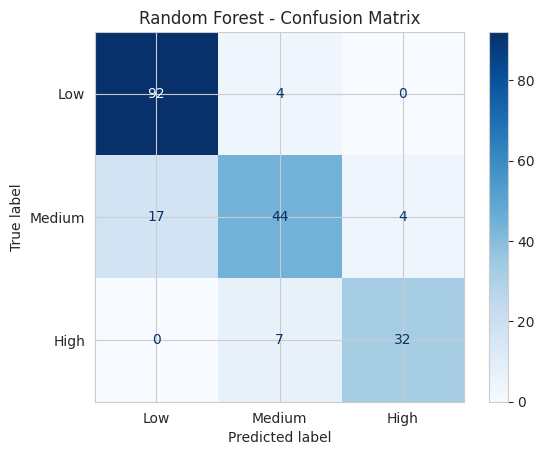

In [12]:
# Confusion matrix for the Random Forest (main model)
rf_preds = rf_pipeline.predict(X_test)
cm = confusion_matrix(y_test, rf_preds, labels=["Low","Medium","High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","Medium","High"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


## 8. Contributing factors (feature importance)

This directly satisfies the "contributing factors" MVP requirement -- showing *why* the model flags a student as at-risk, not just the risk level.


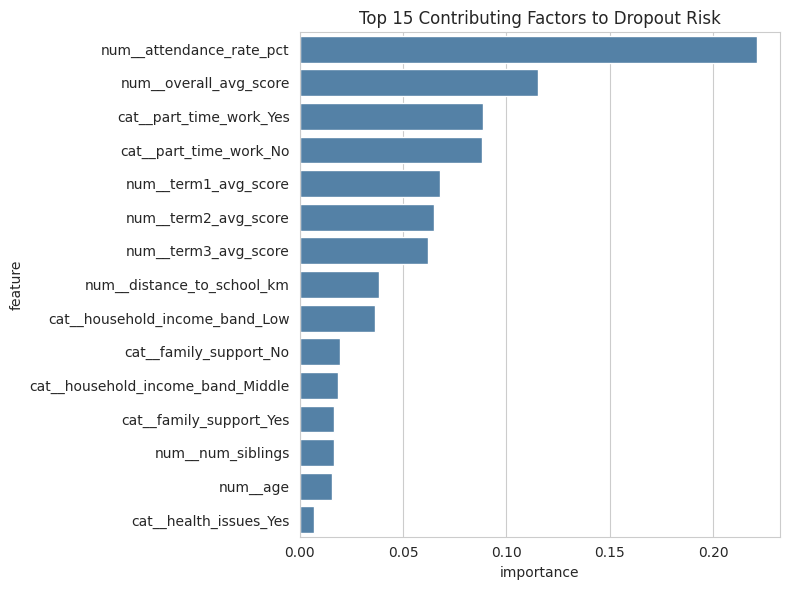

,feature,importance
46,num__attendance_rate_pct,0.221166
50,num__overall_avg_score,0.115496
34,cat__part_time_work_Yes,0.088639
33,cat__part_time_work_No,0.088123
47,num__term1_avg_score,0.067809
48,num__term2_avg_score,0.064834
49,num__term3_avg_score,0.062224
44,num__distance_to_school_km,0.038214
27,cat__household_income_band_Low,0.036662
37,cat__family_support_No,0.019404


In [13]:
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=fi_df, x="importance", y="feature", color="steelblue")
plt.title("Top 15 Contributing Factors to Dropout Risk")
plt.tight_layout()
plt.show()

fi_df


## 9. Save the trained model

In [14]:
joblib.dump(rf_pipeline, "student_dropout_model.pkl")
print("Model saved as student_dropout_model.pkl")


Model saved as student_dropout_model.pkl


## 10. Demo: predict risk for a new student

This is the function you'll wrap into your notebook/CLI/simple app for the 2-3 min demo.


In [15]:
def predict_risk(student_dict):
    """
    student_dict: dict with the same feature columns as X (see printed list below).
    Returns predicted risk level + probability breakdown.
    """
    input_df = pd.DataFrame([student_dict])
    pred = rf_pipeline.predict(input_df)[0]
    proba = rf_pipeline.predict_proba(input_df)[0]
    classes = rf_pipeline.named_steps["model"].classes_
    proba_dict = dict(zip(classes, proba.round(3)))
    return pred, proba_dict

print(list(X.columns))


['state', 'school_type', 'gender', 'age', 'class_level', 'distance_to_school_km', 'household_income_band', 'parent_education_level', 'num_siblings', 'part_time_work', 'has_scholarship', 'family_support', 'health_issues', 'attendance_rate_pct', 'term1_avg_score', 'term2_avg_score', 'term3_avg_score', 'overall_avg_score', 'extracurricular_involvement']


In [17]:
# Example: a student with poor attendance, low income, part-time work
sample_student = {
    "state": "Kano",
    "school_type": "Public",
    "gender": "Male",
    "age": 15,
    "class_level": "SS2",
    "distance_to_school_km": 8.5,
    "household_income_band": "Low",
    "parent_education_level": "Primary",
    "num_siblings": 5,
    "part_time_work": "Yes",
    "has_scholarship": "No",
    "family_support": "No",
    "health_issues": "No",
    "attendance_rate_pct": 58.0,
    "term1_avg_score": 42.0,
    "term2_avg_score": 39.0,
    "term3_avg_score": 35.0,
    "overall_avg_score": 38.7,
    "extracurricular_involvement": "No"
}

risk_level, probabilities = predict_risk(sample_student)
print("Predicted risk level:", risk_level)
print("Probabilities:", probabilities)


Predicted risk level: High
Probabilities: {'High': np.float64(0.94), 'Low': np.float64(0.006), 'Medium': np.float64(0.055)}


## Notes / Limitations
- Dataset is **synthetic**, engineered to reflect known Nigerian dropout patterns (attendance, income, distance, part-time work) -- not collected from real schools.
- `risk_score_raw` was excluded from training features to avoid label leakage.
- For a production version, this would ideally be trained on real school records (e.g., state UBEC/SUBEB data or NBS education statistics).
